In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset"

In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

In [ ]:
dataset = ImageFolder(
    root=dataset_path,
    transform=transform
)

train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Number of images:", len(dataset))
print("Classes:", dataset.classes)

Number of images: 7877
Classes: ['Testing', 'Training']


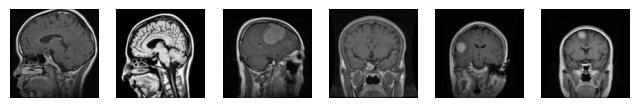

In [ ]:
images,labels = next(iter(train_loader))

plt.figure(figsize=(8,4))

for i in range(6):

    plt.subplot(1,6,i+1)

    img = images[i].squeeze()

    img = img*0.5 + 0.5

    plt.imshow(img,cmap='gray')

    plt.axis('off')

plt.show()

In [ ]:
import os
import shutil

# Original dataset folder (your current structure)
source_path = "/content/drive/MyDrive/Dataset"

# New fixed dataset folder
fixed_path = "/content/drive/MyDrive/Dataset_new"

os.makedirs(fixed_path, exist_ok=True)
os.makedirs(os.path.join(fixed_path, "tumor"), exist_ok=True)
os.makedirs(os.path.join(fixed_path, "no tumor"), exist_ok=True)

folders = ["Training", "Testing"]
classes = ["tumor", "no tumor"]

for folder in folders:
    for cls in classes:

        src_dir = os.path.join(source_path, folder, cls)
        dst_dir = os.path.join(fixed_path, cls)

        if os.path.exists(src_dir):

            for file in os.listdir(src_dir):

                src_file = os.path.join(src_dir, file)
                dst_file = os.path.join(dst_dir, file)

                shutil.copy(src_file, dst_file)

print("Dataset fixed successfully!")
print("New dataset path:", fixed_path)





Dataset fixed successfully!
New dataset path: /content/drive/MyDrive/Dataset_new


In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset_new"

In [ ]:
dataset = ImageFolder(root=dataset_path, transform=transform)

train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

print("Number of images:", len(dataset))
print("Classes:", dataset.classes)

Number of images: 7540
Classes: ['no tumor', 'tumor']


In [ ]:
import os

old_path = "/content/drive/MyDrive/Dataset_new/no tumor"
new_path = "/content/drive/MyDrive/Dataset_new/no_tumor"

os.rename(old_path, new_path)

print("Renamed successfully!")

Renamed successfully!


In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset_new"

dataset = ImageFolder(dataset_path, transform=transform)

train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

print("Number of images:", len(dataset))
print("Classes:", dataset.classes)

Number of images: 7540
Classes: ['no_tumor', 'tumor']


In [ ]:
import torch
import torch.nn as nn

latent_dim = 100

class Generator(nn.Module):

    def __init__(self):
        super(Generator, self).__init__()

        # Label embedding (Tumor / No Tumor)
        self.label_emb = nn.Embedding(2, 50)

        # Fully connected layers
        self.fc = nn.Sequential(

            nn.Linear(latent_dim + 50, 1024),
            nn.ReLU(True),

            nn.Linear(1024, 128*16*16),
            nn.ReLU(True)
        )

        # Upsampling layers (Generate 128x128 images)
        self.conv = nn.Sequential(

            # 16 → 32
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 32 → 64
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            # 64 → 128
            nn.Upsample(scale_factor=2),
            nn.Conv2d(32,1,3,padding=1),

            nn.Tanh()
        )


    def forward(self, z, labels):

        label_input = self.label_emb(labels)

        x = torch.cat([z, label_input], 1)

        x = self.fc(x)

        x = x.view(-1,128,16,16)

        img = self.conv(x)

        return img

In [ ]:
G = Generator().to(device)

print(G)

Generator(
  (label_emb): Embedding(2, 50)
  (fc): Sequential(
    (0): Linear(in_features=150, out_features=1024, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=1024, out_features=32768, bias=True)
    (3): ReLU(inplace=True)
  )
  (conv): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Upsample(scale_factor=2.0, mode='nearest')
    (5): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Upsample(scale_factor=2.0, mode='nearest')
    (9): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): Tanh()
  )
)


In [ ]:
class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        # Label embedding
        self.label_emb = nn.Embedding(2, 128*128)

        self.conv = nn.Sequential(

            # Input channels = Image(1) + Label(1) = 2
            nn.Conv2d(2,32,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128*16*16,1),

            nn.Sigmoid()
        )


    def forward(self, img, labels):

        # Convert labels into image maps
        label_map = self.label_emb(labels)

        label_map = label_map.view(-1,1,128,128)

        x = torch.cat([img,label_map],1)

        x = self.conv(x)

        validity = self.fc(x)

        return validity

In [ ]:
D = Discriminator().to(device)

print(D)

Discriminator(
  (label_emb): Embedding(2, 16384)
  (conv): Sequential(
    (0): Conv2d(2, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=1, bias=True)
    (2): Sigmoid()
  )
)


In [ ]:
D = Discriminator().to(device)

print(D)

Discriminator(
  (label_emb): Embedding(2, 16384)
  (conv): Sequential(
    (0): Conv2d(2, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=1, bias=True)
    (2): Sigmoid()
  )
)


In [ ]:
optimizer_G = torch.optim.Adam(
    G.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = torch.optim.Adam(
    D.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

In [ ]:
num_epochs = 100
latent_dim = 100

In [ ]:
z = torch.randn(4, latent_dim).to(device)

labels = torch.randint(0,2,(4,)).to(device)

fake_images = G(z,labels)

print(fake_images.shape)

torch.Size([4, 1, 128, 128])


In [ ]:
criterion = nn.BCELoss()

In [ ]:
num_epochs = 100

for epoch in range(num_epochs):

    for imgs, labels in train_loader:

        batch_size = imgs.size(0)

        imgs = imgs.to(device)
        labels = labels.to(device)

        real = torch.ones(batch_size,1).to(device)
        fake = torch.zeros(batch_size,1).to(device)

        # ---------------------
        # Train Generator
        # ---------------------

        optimizer_G.zero_grad()

        z = torch.randn(batch_size, latent_dim).to(device)

        gen_labels = torch.randint(0,2,(batch_size,)).to(device)

        gen_imgs = G(z, gen_labels)

        g_loss = criterion(D(gen_imgs, gen_labels), real)

        g_loss.backward()

        optimizer_G.step()

        # ---------------------
        # Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        real_loss = criterion(D(imgs, labels), real)

        fake_loss = criterion(D(gen_imgs.detach(), gen_labels), fake)

        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()

        optimizer_D.step()


    print(f"Epoch [{epoch+1}/{num_epochs}]  "
          f"G Loss: {g_loss.item():.4f}  "
          f"D Loss: {d_loss.item():.4f}")

Epoch [1/100]  G Loss: 1.0080  D Loss: 0.7331
Epoch [2/100]  G Loss: 0.8510  D Loss: 0.6961
Epoch [3/100]  G Loss: 0.7173  D Loss: 0.7663
Epoch [4/100]  G Loss: 0.5648  D Loss: 0.5080
Epoch [5/100]  G Loss: 2.1718  D Loss: 0.5983
Epoch [6/100]  G Loss: 1.6613  D Loss: 0.6907
Epoch [7/100]  G Loss: 2.3666  D Loss: 0.6603
Epoch [8/100]  G Loss: 3.3412  D Loss: 0.2171
Epoch [9/100]  G Loss: 0.4471  D Loss: 0.5816
Epoch [10/100]  G Loss: 0.0404  D Loss: 1.6572
Epoch [11/100]  G Loss: 1.3586  D Loss: 0.3008
Epoch [12/100]  G Loss: 2.2910  D Loss: 0.6582
Epoch [13/100]  G Loss: 2.1985  D Loss: 0.5756
Epoch [14/100]  G Loss: 1.0179  D Loss: 0.6545
Epoch [15/100]  G Loss: 0.7211  D Loss: 0.5034
Epoch [16/100]  G Loss: 2.8223  D Loss: 0.2675
Epoch [17/100]  G Loss: 2.2043  D Loss: 0.7647
Epoch [18/100]  G Loss: 0.4700  D Loss: 0.5674
Epoch [19/100]  G Loss: 0.9584  D Loss: 0.5297
Epoch [20/100]  G Loss: 2.4316  D Loss: 0.2635
Epoch [21/100]  G Loss: 0.8782  D Loss: 0.4195
Epoch [22/100]  G Loss

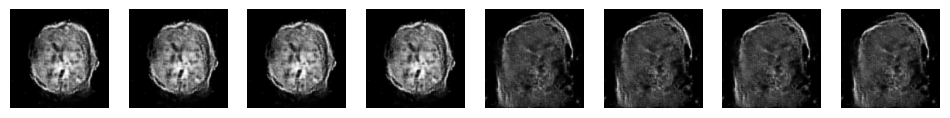

In [ ]:
G.eval()

z = torch.randn(8,latent_dim).to(device)

labels = torch.tensor([0,0,0,0,1,1,1,1]).to(device)

with torch.no_grad():
    fake_images = G(z,labels)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

for i in range(8):

    img = fake_images[i].cpu().squeeze()

    img = img*0.5 + 0.5

    plt.subplot(1,8,i+1)
    plt.imshow(img,cmap='gray')
    plt.axis('off')

plt.show()

In [ ]:
import cv2

img_128 = fake_images[0].cpu().squeeze().numpy()

img_512 = cv2.resize(img_128, (512,512), interpolation=cv2.INTER_CUBIC)

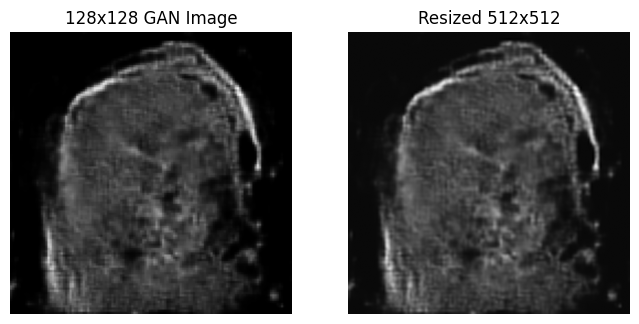

In [ ]:
import cv2
import matplotlib.pyplot as plt

G.eval()

# Generate one GAN image
z = torch.randn(1, latent_dim).to(device)
label = torch.tensor([1]).to(device)  # 1 = tumor (or use 0 for no_tumor)

with torch.no_grad():
    fake_image = G(z, label)

# Convert to numpy
img_128 = fake_image[0].cpu().squeeze().numpy()

# Convert from [-1,1] → [0,1]
img_128 = img_128*0.5 + 0.5

# Resize to 512x512
img_512 = cv2.resize(img_128, (512,512), interpolation=cv2.INTER_CUBIC)

# Show comparison
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_128, cmap='gray')
plt.title("128x128 GAN Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_512, cmap='gray')
plt.title("Resized 512x512")
plt.axis('off')

plt.show()

In [ ]:
import os
import cv2
import torch

G.eval()

# Output folders
save_path = "/content/drive/MyDrive/GAN_Synthetic"

tumor_path = os.path.join(save_path, "tumor")
notumor_path = os.path.join(save_path, "no_tumor")

os.makedirs(tumor_path, exist_ok=True)
os.makedirs(notumor_path, exist_ok=True)

num_images = 1000

# -----------------
# Generate Tumor Images
# -----------------

for i in range(num_images):

    z = torch.randn(1, latent_dim).to(device)

    label = torch.tensor([1]).to(device)  # tumor

    with torch.no_grad():

        fake = G(z, label)

    img = fake[0].cpu().squeeze().numpy()

    # Convert [-1,1] → [0,1]
    img = img*0.5 + 0.5

    # Resize to 512x512
    img = cv2.resize(img, (512,512), interpolation=cv2.INTER_CUBIC)

    img = (img*255).astype("uint8")

    cv2.imwrite(f"{tumor_path}/tumor_{i}.png", img)


print("Tumor images generated")


# -----------------
# Generate No Tumor Images
# -----------------

for i in range(num_images):

    z = torch.randn(1, latent_dim).to(device)

    label = torch.tensor([0]).to(device)  # no tumor

    with torch.no_grad():

        fake = G(z, label)

    img = fake[0].cpu().squeeze().numpy()

    img = img*0.5 + 0.5

    img = cv2.resize(img, (512,512), interpolation=cv2.INTER_CUBIC)

    img = (img*255).astype("uint8")

    cv2.imwrite(f"{notumor_path}/notumor_{i}.png", img)


print("No Tumor images generated")
print("All 2000 images saved successfully")

Tumor images generated
No Tumor images generated
All 2000 images saved successfully


In [ ]:
import os
import cv2
import torch

G.eval()

# Output folders
save_path = "/content/drive/MyDrive/GAN_Synthetic"

tumor_path = os.path.join(save_path, "tumor")
notumor_path = os.path.join(save_path, "no_tumor")

os.makedirs(tumor_path, exist_ok=True)
os.makedirs(notumor_path, exist_ok=True)

num_images = 1000

# -----------------
# Generate Tumor Images
# -----------------

for i in range(num_images):

    z = torch.randn(1, latent_dim).to(device)

    label = torch.tensor([1]).to(device)  # tumor

    with torch.no_grad():

        fake = G(z, label)

    img = fake[0].cpu().squeeze().numpy()

    # Convert [-1,1] → [0,1]
    img = img*0.5 + 0.5

    # Resize to 512x512
    img = cv2.resize(img, (512,512), interpolation=cv2.INTER_CUBIC)

    img = (img*255).astype("uint8")

    cv2.imwrite(f"{tumor_path}/tumor_{i}.png", img)


print("Tumor images generated")


# -----------------
# Generate No Tumor Images
# -----------------

for i in range(num_images):

    z = torch.randn(1, latent_dim).to(device)

    label = torch.tensor([0]).to(device)  # no tumor

    with torch.no_grad():

        fake = G(z, label)

    img = fake[0].cpu().squeeze().numpy()

    img = img*0.5 + 0.5

    img = cv2.resize(img, (512,512), interpolation=cv2.INTER_CUBIC)

    img = (img*255).astype("uint8")

    cv2.imwrite(f"{notumor_path}/notumor_{i}.png", img)


print("No Tumor images generated")
print("All 2000 images saved successfully")

Tumor images generated
No Tumor images generated
All 2000 images saved successfully


In [ ]:
import os

notumor_path = "/content/drive/MyDrive/GAN_Synthetic/no_tumor"

print("Folder exists:", os.path.exists(notumor_path))

if os.path.exists(notumor_path):
    print("Files inside:", len(os.listdir(notumor_path)))

Folder exists: True
Files inside: 1000


In [ ]:
import os
import cv2
import torch

G.eval()

notumor_path = "/content/drive/MyDrive/GAN_Synthetic/no_tumor"
os.makedirs(notumor_path, exist_ok=True)

num_images = 1000

for i in range(num_images):

    z = torch.randn(1, latent_dim).to(device)

    label = torch.tensor([0]).to(device)   # no tumor

    with torch.no_grad():
        fake = G(z, label)

    img = fake[0].cpu().squeeze().numpy()

    img = img*0.5 + 0.5

    img = cv2.resize(img, (512,512), interpolation=cv2.INTER_CUBIC)

    img = (img*255).astype("uint8")

    cv2.imwrite(f"{notumor_path}/notumor_{i}.png", img)


print("No Tumor images generated successfully")

No Tumor images generated successfully


In [ ]:
print(len(os.listdir("/content/drive/MyDrive/GAN_Synthetic/no_tumor")))

1000


In [ ]:
import os
import cv2
import torch
import numpy as np

G.eval()

tumor_path = "/content/drive/MyDrive/GAN_Synthetic/tumor"
os.makedirs(tumor_path, exist_ok=True)

num_images = 1000

for i in range(num_images):

    # Structured sampling (much more diverse)
    z = torch.randn(1, latent_dim).to(device)

    z[:, :50] *= 2.5
    z[:, 50:] *= 0.5

    label = torch.tensor([1]).to(device)

    with torch.no_grad():
        fake = G(z, label)

    img = fake[0].cpu().squeeze().numpy()

    img = img*0.5 + 0.5

    img = cv2.resize(img,(512,512),interpolation=cv2.INTER_CUBIC)

    img = (img*255).astype("uint8")

    cv2.imwrite(f"{tumor_path}/tumor_{i}.png",img)

print("Diverse tumor images generated")

Diverse tumor images generated


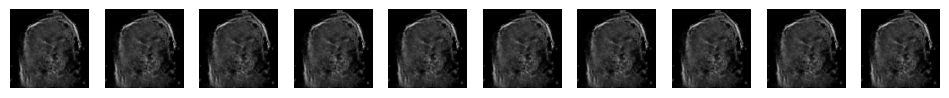

In [ ]:
import matplotlib.pyplot as plt
import os
import cv2

folder = "/content/drive/MyDrive/GAN_Synthetic/tumor"

files = os.listdir(folder)[:10]

plt.figure(figsize=(12,4))

for i,f in enumerate(files):

    img = cv2.imread(folder+"/"+f,0)

    plt.subplot(1,10,i+1)

    plt.imshow(img,cmap='gray')

    plt.axis('off')

plt.show()

In [ ]:
import torch

save_path = "/content/drive/MyDrive/GAN_Model"

import os
os.makedirs(save_path, exist_ok=True)

# Save Generator
torch.save(G.state_dict(),
           save_path + "/generator.pth")

# Save Discriminator
torch.save(D.state_dict(),
           save_path + "/discriminator.pth")

print("GAN model saved to Drive successfully!")

GAN model saved to Drive successfully!


In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/GAN_Model/generator.pth")
files.download("/content/drive/MyDrive/GAN_Model/discriminator.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>